# 01 · EDA and data quality
**Goal:** understand the target, find the data problems *before* modeling, and form hypotheses
that the later notebooks test. Sections: class balance, undocumented codes, outliers, signal.

In [1]:
import sys, glob, warnings
sys.path.insert(0, "..")            # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50, "display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

from src import features as ft, evaluate as ev, train as tr, fairness as fr

DATA = sorted(glob.glob("../data/*.xls*") + glob.glob("../data/*.csv"))[0]   # see data/README.md
print("Using", DATA)

Using ../data\default_of_credit_card_clients.xls


In [2]:
raw = ft.load_raw(DATA)
print(raw.shape)
raw.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1. Class balance
About 22% of customers default. Accuracy would reward a model that says 'nobody defaults' (~78%), so we will use PR-AUC and cost-based metrics.

Default rate: 22.1%  |  always-predict-no-default accuracy: 77.9%


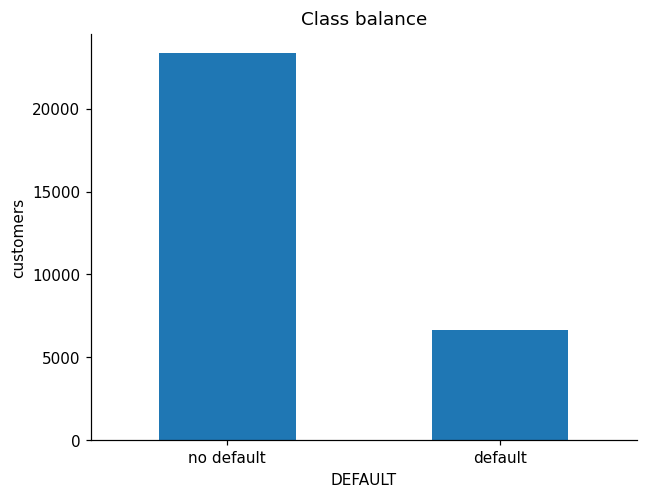

In [3]:
rate = raw[ft.TARGET].mean()
print(f"Default rate: {rate:.1%}  |  always-predict-no-default accuracy: {1-rate:.1%}")
raw[ft.TARGET].value_counts().rename({0: "no default", 1: "default"}).plot.bar(rot=0, title="Class balance")
plt.ylabel("customers"); plt.savefig("../reports/figures/eda_class_balance.png", bbox_inches="tight")

## 2. Data quality: undocumented codes and oddities
The UCI documentation lists EDUCATION 1-4, MARRIAGE 1-3 and PAY_x as -1 or 1-9. The data contain other values. Flagging this is part of the job.

In [4]:
ft.data_quality_report(raw)

,issue,rows,pct,note
0,Duplicate rows,35,0.12,Exact duplicates (the dataset ships with a few)
1,"EDUCATION in {0,5,6}",345,1.15,Undocumented codes; merged into 'Other' (4)
2,MARRIAGE == 0,54,0.18,Undocumented code; merged into 'Other' (3)
3,PAY_x == -2,6561,21.87,Undocumented. Most plausibly 'no consumption'
4,PAY_x == 0,21173,70.58,Undocumented. Most plausibly 'revolving credit...
5,Negative BILL_AMT,1930,6.43,Credit balance / refunds
6,BILL_AMT > LIMIT_BAL,3931,13.10,Over-limit statements
7,All six PAY_AMT == 0,1432,4.77,Customers who never paid in the window
8,AGE > 70,15,0.05,Sparse tail; fairness estimates for these ages...


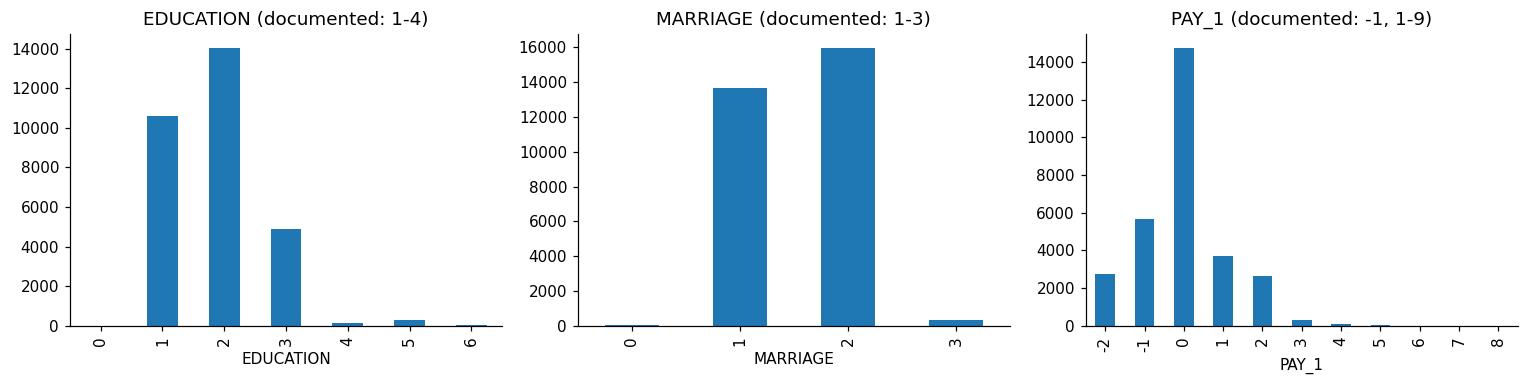

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
raw["EDUCATION"].value_counts().sort_index().plot.bar(ax=ax[0], title="EDUCATION (documented: 1-4)")
raw["MARRIAGE"].value_counts().sort_index().plot.bar(ax=ax[1], title="MARRIAGE (documented: 1-3)")
raw["PAY_1"].value_counts().sort_index().plot.bar(ax=ax[2], title="PAY_1 (documented: -1, 1-9)")
plt.tight_layout(); plt.savefig("../reports/figures/eda_undocumented_codes.png", bbox_inches="tight")

**Decisions** (documented, since a reviewer will ask):
* EDUCATION 0/5/6 → merged into 4 ("Other"); MARRIAGE 0 → 3 ("Other").
* PAY_x values -2 and 0 are undocumented. Their default rates (below) show they behave differently from -1,
  so we **keep them as distinct ordinal values** instead of collapsing them. Trees can use them directly and
  we add count features (`N_REVOLVING`, `N_NO_CONSUMPTION`, ...).
* Duplicate rows are dropped.

,default_rate,n
PAY_1,,
-2,0.132364,2750
-1,0.167899,5682
0,0.128113,14737
1,0.340333,3667
2,0.691298,2666
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


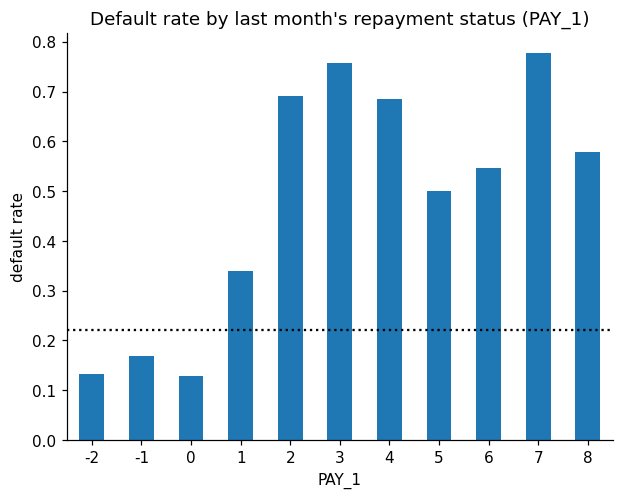

In [6]:
df = ft.add_group_labels(ft.clean(raw))
# Default rate by repayment status: the strongest signal in this dataset
rate_by_pay = df.groupby("PAY_1")[ft.TARGET].agg(["mean", "size"]).rename(columns={"mean": "default_rate", "size": "n"})
display(rate_by_pay)
ax = rate_by_pay["default_rate"].plot.bar(rot=0, title="Default rate by last month's repayment status (PAY_1)")
ax.axhline(df[ft.TARGET].mean(), color="k", ls=":"); ax.set_ylabel("default rate")
plt.savefig("../reports/figures/eda_default_by_pay1.png", bbox_inches="tight")

## 3. Outliers and heavy tails
Bill and payment amounts are heavily right-skewed, include negative bills (credit balances) and over-limit statements. Trees are insensitive to this; logistic regression is not, which is one reason to build ratio features.

       LIMIT_BAL  BILL_AMT1  PAY_AMT1      AGE
count    29965.0    29965.0   29965.0  29965.0
mean    167442.0    51283.0    5670.0     35.0
std     129760.0    73658.0   16572.0      9.0
min      10000.0  -165580.0       0.0     21.0
1%       10000.0      -81.0       0.0     22.0
50%     140000.0    22438.0    2102.0     34.0
99%     500000.0   350134.0   66843.0     60.0
max    1000000.0   964511.0  873552.0     79.0
Negative bills: 1930 | statements above limit: 3931


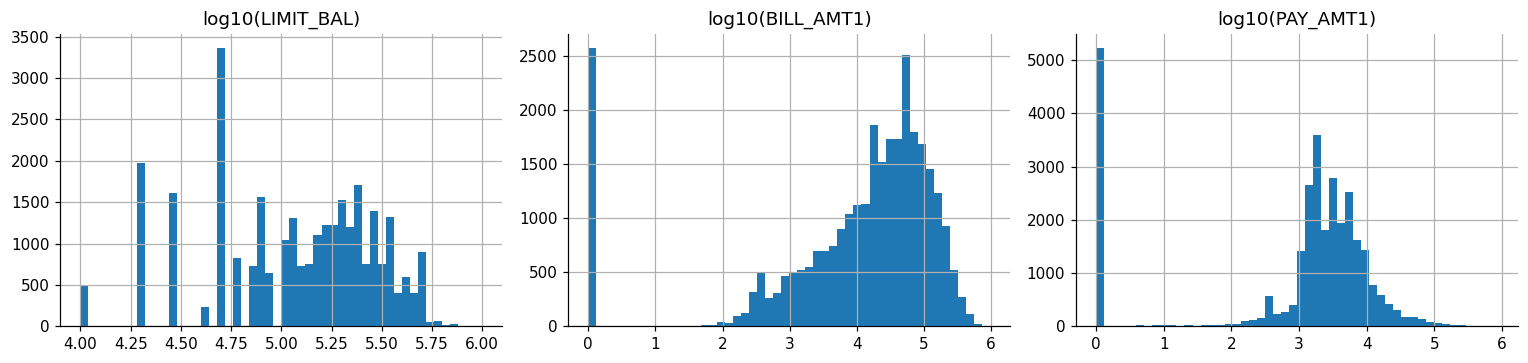

In [7]:
cols = ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]
print(df[cols + ["AGE"]].describe(percentiles=[.01, .5, .99]).round(0))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
for a, c in zip(ax, cols):
    np.log10(df[c].clip(lower=1)).hist(bins=50, ax=a); a.set_title(f"log10({c})")
plt.tight_layout(); plt.savefig("../reports/figures/eda_skew.png", bbox_inches="tight")
print("Negative bills:", int((df[ft.BILL_COLS] < 0).any(axis=1).sum()),
      "| statements above limit:", int(df[ft.BILL_COLS].gt(df.LIMIT_BAL, axis=0).any(axis=1).sum()))

## 4. Signal: payment behavior vs. demographics
Behavioral features should dominate. Demographics should be weaker, which matters for the fairness section (we want to be able to drop SEX/MARRIAGE at little cost).

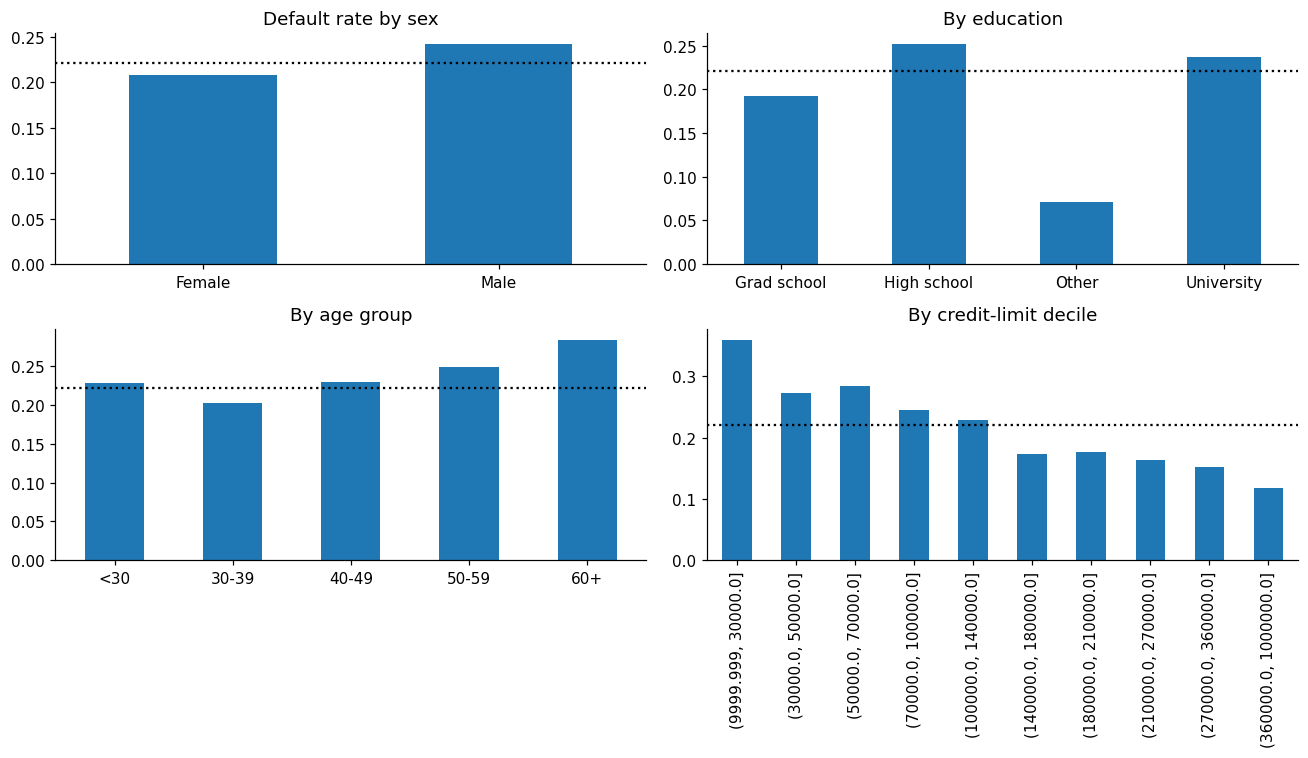

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
df.groupby("SEX_LABEL")[ft.TARGET].mean().plot.bar(ax=ax[0, 0], rot=0, title="Default rate by sex")
df.groupby("EDU_LABEL")[ft.TARGET].mean().plot.bar(ax=ax[0, 1], rot=0, title="By education")
df.groupby("AGE_GROUP")[ft.TARGET].mean().reindex(["<30", "30-39", "40-49", "50-59", "60+"]).plot.bar(ax=ax[1, 0], rot=0, title="By age group")
df.groupby(pd.qcut(df.LIMIT_BAL, 10, duplicates="drop"), observed=True)[ft.TARGET].mean().plot.bar(ax=ax[1, 1], title="By credit-limit decile")
for a in ax.ravel(): a.set_xlabel(""); a.axhline(df[ft.TARGET].mean(), color="k", ls=":")
plt.tight_layout(); plt.savefig("../reports/figures/eda_default_by_group.png", bbox_inches="tight")

In [9]:
# Engineered features: do they separate the classes better than the raw ones?
Xe, y = ft.get_xy(df)
corr = Xe.corrwith(y).sort_values(key=abs, ascending=False)
corr.head(12).to_frame("corr_with_default")

,corr_with_default
N_DELAYED,0.398406
PAY_MAX,0.331082
PAY_1,0.324964
PAY_MEAN,0.281989
PAY_2,0.263656
PAY_3,0.235230
PAY_4,0.216551
PAY_5,0.204059
PAY_6,0.186740
N_ZERO_PAYMENTS,0.164273


## Takeaways to write up
* Class balance & why accuracy is the wrong metric.
* The undocumented codes and how you resolved each.
* Which signals dominate (expect recent repayment status), and how strong the demographic signal is.
* Anything surprising (e.g. PAY = -2 / 0 behave differently from -1).